In [1]:

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.mode.copy_on_write = True


## Configuration

In [2]:
RETS_CSV = "sp500_returns_with_tickers.csv"  
CAPS_CSV = "sp500_market_caps.csv"          

WINDOW = 36
DATA_FREQ = "M"


OUT_DIR = Path("/mnt/data")
OUT_DIR.mkdir(parents=True, exist_ok=True)
BETAS_OUT    = OUT_DIR / f"betas_w{WINDOW}.parquet"
WEIGHTS_OUT  = OUT_DIR / f"weights_eabc_w{WINDOW}.parquet"
RETURNS_OUT  = OUT_DIR / f"portfolio_returns_w{WINDOW}.parquet"

## Load CSVs and convert to Parquet for faster subsequent runs

In [3]:

def _read_csv(path):
    return pd.read_csv(path, index_col=0, parse_dates=True)

rets = _read_csv(RETS_CSV)
caps = _read_csv(CAPS_CSV)

# Downcast memory
rets = rets.astype("float32")
caps = caps.astype("float32")

# Save Parquet for speed next time
rets.to_parquet(RETS_CSV.replace(".csv", ".parquet"), compression="zstd")
caps.to_parquet(CAPS_CSV.replace(".csv", ".parquet"), compression="zstd")

print("Loaded:", rets.shape, caps.shape)


Loaded: (780, 1863) (780, 1863)


## Align indexes and optionally resample to monthly

In [4]:
# Align intersection of dates and tickers
common_index = rets.index.intersection(caps.index)
common_cols  = rets.columns.intersection(caps.columns)
rets = rets.loc[common_index, common_cols].sort_index()
caps = caps.loc[common_index, common_cols].sort_index()

if DATA_FREQ is not None:
    # Returns should be compounded within period
    compound = lambda df: (1.0 + df).prod() - 1.0
    rets = rets.resample(DATA_FREQ).apply(compound)
    # For caps, use period-end levels (last value)
    caps = caps.resample(DATA_FREQ).last()

print("After resample/alignment:", rets.shape, caps.shape)

C:\Users\Username\AppData\Local\Temp\ipykernel_74812\933873597.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rets = rets.resample(DATA_FREQ).apply(compound)


After resample/alignment: (780, 1863) (780, 1863)


C:\Users\Username\AppData\Local\Temp\ipykernel_74812\933873597.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  caps = caps.resample(DATA_FREQ).last()


## Derive cap weights and market return (`ret_cap`)

In [5]:
# Cap weights per date (normalize row-wise)
cap_weights = caps.div(caps.sum(axis=1), axis=0).fillna(0.0)

# Market (cap-weighted) return
ret_cap = (rets * cap_weights).sum(axis=1).astype("float32")
ret_cap.name = "ret_cap"

print("ret_cap:", ret_cap.shape, "nan%", ret_cap.isna().mean()*100)

ret_cap: (780,) nan% 0.0


## Vectorized rolling beta vs. cap-weighted market

In [6]:
def rolling_beta_matrix(rets_df: pd.DataFrame, market_ret: pd.Series, window: int) -> pd.DataFrame:
    mean_R = rets_df.rolling(window, min_periods=window).mean()
    mean_M = market_ret.rolling(window, min_periods=window).mean()

    EXY   = (rets_df.mul(market_ret, axis=0)).rolling(window, min_periods=window).mean()
    covRM = EXY - mean_R.mul(mean_M, axis=0)

    EM2   = (market_ret.pow(2)).rolling(window, min_periods=window).mean()
    varM  = EM2 - mean_M.pow(2)

    betas = covRM.div(varM, axis=0)
    return betas

t0 = time.time()
betas = rolling_beta_matrix(rets, ret_cap, WINDOW).astype("float32")
t1 = time.time()
print(f"Betas computed in {t1 - t0:.2f}s ; shape={betas.shape}")
betas.to_parquet(BETAS_OUT, compression="zstd")

Betas computed in 0.39s ; shape=(780, 1863)


## Closed-form Equal-Absolute-Beta-Contribution (EABC) weights

In [7]:
def eabc_weights_from_betas(betas: pd.DataFrame) -> pd.DataFrame:
    inv_abs = 1.0 / betas.abs()
    inv_abs = inv_abs.replace([np.inf, -np.inf], np.nan)
    w = inv_abs.div(inv_abs.sum(axis=1), axis=0)
    return w.fillna(0.0).astype("float32")

w_eabc = eabc_weights_from_betas(betas)
w_eabc.to_parquet(WEIGHTS_OUT, compression="zstd")
print("Weights shape:", w_eabc.shape)

Weights shape: (780, 1863)


## Portfolio returns: EABC and Cap-Weighted

In [8]:
cap_w_lag  = cap_weights.shift(1)
eabc_w_lag = w_eabc.shift(1)

cap_w_lag  = cap_w_lag.div(cap_w_lag.sum(axis=1), axis=0)
eabc_w_lag = eabc_w_lag.div(eabc_w_lag.sum(axis=1), axis=0)

cap_port_full  = (rets * cap_w_lag).sum(axis=1).astype("float32") 
cap_port_full.name = "CW_full"

port_eabc = (rets * eabc_w_lag).sum(axis=1).astype("float32")    
port_eabc.name = f"EBC_{WINDOW}"


valid_mask = eabc_w_lag.notna() & (eabc_w_lag != 0.0)  
cap_w_same = cap_w_lag.where(valid_mask, 0.0)
cap_w_same = cap_w_same.div(cap_w_same.sum(axis=1), axis=0)

ew_w = rets.notna().astype("float32")
ew_w = ew_w.div(ew_w.sum(axis=1), axis=0).fillna(0.0).shift(1)
ew_w_same = ew_w.where(valid_mask, 0.0)
ew_w_same = ew_w_same.div(ew_w_same.sum(axis=1), axis=0)


cap_port_same = (rets * cap_w_same).sum(axis=1).astype("float32")
cap_port_same.name = "CW"   

ew_port_same = (rets * ew_w_same).sum(axis=1).astype("float32")
ew_port_same.name = "EW"


cw_ebc_same = (cap_port_same - port_eabc).rename("CW-EBC")
cw_ew_same  = (cap_port_same - ew_port_same).rename("CW-EW")


cw_ebc_full = (cap_port_full - port_eabc).rename("CW-EBC_fullUniverse")

portfolio_returns = pd.DataFrame({
    "CW": cap_port_same,
    "CW-EBC": cw_ebc_same,
    "CW-EW": cw_ew_same,
    f"EBC_{WINDOW}": port_eabc,
    "CW_full": cap_port_full,
    "CW-EBC_fullUniverse": cw_ebc_full
}).dropna()

portfolio_returns.to_parquet(RETURNS_OUT, compression="zstd")
portfolio_returns.tail()

,CW,CW-EBC,CW-EW,EBC_36,CW_full,CW-EBC_fullUniverse
date,,,,,,
2024-08-31,0.024274,-0.021010,0.001621,0.045284,0.024283,-0.021001
2024-09-30,0.022573,0.012929,0.001678,0.009644,0.022573,0.012929
2024-10-31,-0.008678,0.019425,0.006133,-0.028103,-0.008689,0.019414
2024-11-30,0.060234,-0.513627,0.004467,0.573862,0.060234,-0.513627
2024-12-31,-0.023401,0.021150,0.033753,-0.044551,-0.023401,0.021150


## Quick plots

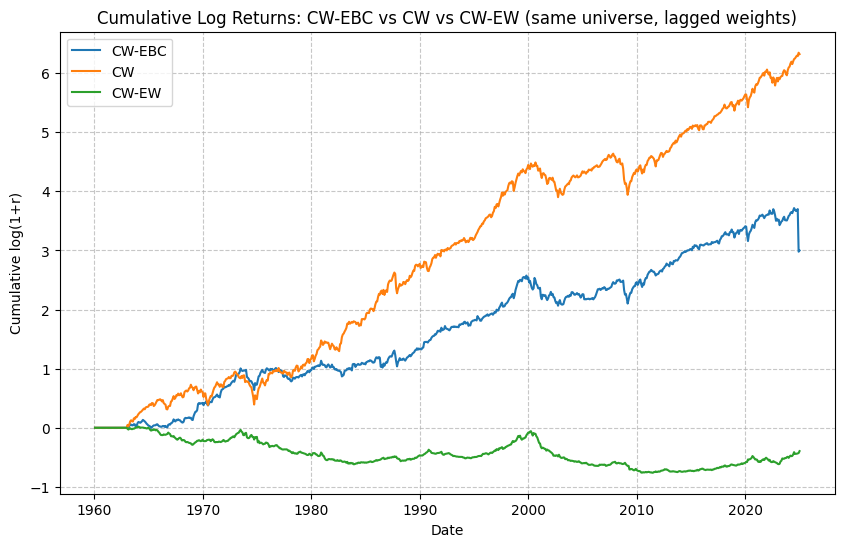

In [9]:
import numpy as np
import matplotlib.pyplot as plt

df = portfolio_returns[["CW-EBC", "CW", "CW-EW"]].dropna().sort_index()
cum = np.log1p(df).cumsum()

plt.figure(figsize=(10,6))
for col in cum.columns:
    plt.plot(cum.index, cum[col], label=col)
plt.title("Cumulative Log Returns: CW-EBC vs CW vs CW-EW (same universe, lagged weights)")
plt.xlabel("Date")
plt.ylabel("Cumulative log(1+r)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [10]:
ff5 = pd.read_csv(r"C:\Users\Username\OneDrive\Desktop\Invesco_project\F-F_Research_Data_5_Factors_2x3.csv", skiprows =3, nrows =742)
ff5.rename(columns={"Unnamed: 0": "Date"}, inplace=True)
ff5["Date"] = pd.to_datetime(ff5["Date"], format="%Y%m")
ff5.set_index("Date", inplace=True)
ff5 = ff5.astype(float) / 100

ffm = pd.read_csv(r"C:\Users\Username\OneDrive\Desktop\Invesco_project\F-F_Momentum_Factor.csv",skiprows= 13, nrows = 1180)
ffm.rename(columns={"Unnamed: 0": "Date"}, inplace=True)
ffm["Date"] = pd.to_datetime(ffm["Date"], format="%Y%m")
ffm.set_index("Date", inplace=True)
ffm = ffm.astype(float) / 100

ff = ff5.join(ffm, how="inner")
ff

,Mkt-RF,SMB,HML,RMW,CMA,RF,Mom
Date,,,,,,,
1963-07-01,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0027,0.0101
1963-08-01,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0025,0.0100
1963-09-01,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0027,0.0012
1963-10-01,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0029,0.0313
1963-11-01,-0.0086,-0.0085,0.0173,-0.0043,0.0227,0.0027,-0.0078
...,...,...,...,...,...,...,...
2024-12-01,-0.0315,-0.0384,-0.0300,0.0191,-0.0121,0.0037,-0.0030
2025-01-01,0.0280,-0.0122,0.0162,-0.0233,-0.0324,0.0037,0.0095
2025-02-01,-0.0243,-0.0493,0.0491,0.0109,0.0306,0.0033,-0.0082


In [11]:
ff_p = ff.copy()
ff_p.index = ff_p.index.to_period("M")  

pref = portfolio_returns[["CW-EBC", "CW-EW", "CW"]].copy()
pref_p = pref.copy()
pref_p.index = pref_p.index.to_period("M")

idx_p = pref_p.index.intersection(ff_p.index)
pref_p = pref_p.loc[idx_p].astype(float)
ff_p   = ff_p.loc[idx_p].astype(float)

print("Aligned (PeriodIndex) span:", idx_p.min(), "→", idx_p.max(), "| rows:", len(idx_p))

pref_m = pref_p.copy()
ff_m   = ff_p.copy()
pref_m.index = pref_m.index.to_timestamp(how="end")
ff_m.index   = ff_m.index.to_timestamp(how="end")

Aligned (PeriodIndex) span: 1963-07 → 2024-12 | rows: 738


In [27]:
df_aligned = pd.concat(
    [
        pref_m[["CW-EBC", "CW-EW"]],
        ff_m[["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]],
    ],
    axis=1,
).dropna()

desc = df_aligned[["CW-EBC", "CW-EW"]].describe().T[["mean", "std", "min", "max"]]
desc["Sharpe_annual"] = desc["mean"] / desc["std"] * np.sqrt(12)
display(desc)

print("Corrs:")
corrs = df_aligned.corr().loc[
    ["CW-EBC", "CW-EW"], ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]
]
display(corrs)

,mean,std,min,max,Sharpe_annual
CW-EBC,0.004889,0.039167,-0.513627,0.190815,0.432403
CW-EW,-0.000396,0.014479,-0.088552,0.050574,-0.094771


Corrs:


,Mkt-RF,SMB,HML,RMW,CMA,Mom
CW-EBC,0.479297,-0.067753,-0.104540,-0.050029,-0.184912,-0.128944
CW-EW,0.076073,-0.594278,-0.445336,0.055259,-0.314044,0.330932


In [13]:
import statsmodels.api as sm

X = sm.add_constant(df_aligned[["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"]])
for fac in ["CW-EBC", "CW-EW"]:
    y = df_aligned[fac]
    m = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
    print("="*24, fac, "="*24)
    print(m.summary())
    print("Annualized alpha:", float(m.params["const"]) * 12, "\n")

======================== CW-EBC ========================
                            OLS Regression Results                            
Dep. Variable:                 CW-EBC   R-squared:                       0.277
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     27.37
Date:                Mon, 18 Aug 2025   Prob (F-statistic):           1.56e-29
Time:                        08:10:34   Log-Likelihood:                 1464.1
No. Observations:                 738   AIC:                            -2914.
Df Residuals:                     731   BIC:                            -2882.
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

In [14]:
import numpy as np
import pandas as pd

def to_month_end(s):
    out = s.copy()
    out.index = pd.PeriodIndex(out.index, freq="M").to_timestamp(how="end")
    return out

def clean_numeric(x):
    if isinstance(x, pd.Series):
        x = pd.to_numeric(x, errors="coerce")
        return x.replace([np.inf, -np.inf], np.nan).astype("float64")
    else:
        x = x.apply(pd.to_numeric, errors="coerce")
        return x.replace([np.inf, -np.inf], np.nan).astype("float64")

rets        = to_month_end(rets)
pref_series = to_month_end(pref_m["CW-EBC"])    
mkt_series  = to_month_end(ff_m["Mkt-RF"])

rets        = clean_numeric(rets)
pref_series = clean_numeric(pref_series)
mkt_series  = clean_numeric(mkt_series)

common_idx  = rets.index.intersection(pref_series.index).intersection(mkt_series.index)
rets        = rets.loc[common_idx]
pref_series = pref_series.loc[common_idx]
mkt_series  = mkt_series.loc[common_idx]

print("Aligned span:", rets.index.min(), "→", rets.index.max(), " | months:", len(rets))


Aligned span: 1963-07-31 23:59:59.999999999 → 2024-12-31 23:59:59.999999999  | months: 738


In [15]:
import statsmodels.api as sm

def nw_mean_t(series: pd.Series, lags: int = 6):
    y = pd.to_numeric(pd.Series(series), errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    if len(y) == 0:
        return np.nan, np.nan, np.nan
    y_arr = y.to_numpy(dtype="float64")
    X_arr = np.ones((len(y_arr), 1), dtype="float64")
    res = sm.OLS(y_arr, X_arr).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    mean = float(res.params[0]); se = float(res.bse[0])
    tval = mean / se if se > 0 else np.nan
    return mean, se, tval


def rolling_beta_single_factor(returns_df: pd.DataFrame, factor: pd.Series, window: int = 36) -> pd.DataFrame:
    R = returns_df.astype("float32"); f = factor.astype("float32")
    mean_R = R.rolling(window, min_periods=window).mean()
    mean_f = f.rolling(window, min_periods=window).mean()
    EXY    = (R.mul(f, axis=0)).rolling(window, min_periods=window).mean()
    covRf  = EXY - mean_R.mul(mean_f, axis=0)
    Ef2    = (f.pow(2)).rolling(window, min_periods=window).mean()
    var_f  = Ef2 - mean_f.pow(2)
    return covRf.div(var_f, axis=0)

def fama_macbeth(rets: pd.DataFrame,
                 pref_series: pd.Series,
                 mkt_series: pd.Series | None = None,
                 window: int = 36,
                 nw_lags: int = 6,
                 min_stocks: int = 50,
                 verbose: bool = True):

    idx = rets.index
    if mkt_series is not None:
        idx = idx.intersection(mkt_series.index)
    idx = idx.intersection(pref_series.index)
    R      = rets.loc[idx].astype("float64")
    f_pref = pref_series.loc[idx].astype("float64")
    f_mkt  = mkt_series.loc[idx].astype("float64") if mkt_series is not None else None

    beta_pref = rolling_beta_single_factor(R, f_pref, window=window).shift(1)
    beta_mkt  = rolling_beta_single_factor(R, f_mkt,  window=window).shift(1) if f_mkt is not None else None

    valid_mask = beta_pref.notna().any(axis=1)
    dates_all  = beta_pref.index[valid_mask].to_list()
    if len(dates_all) < 2:
        raise ValueError("No usable data.")

    lambdas, lambdas_mkt, r2_cs, Ns = [], [], [], []
    kept_months = skipped_smallN = skipped_allNaN = 0

    for i in range(len(dates_all) - 1):
        t  = dates_all[i]
        t1 = dates_all[i + 1]

        X = pd.DataFrame({"beta_pref": beta_pref.loc[t]})
        if beta_mkt is not None:
            X["beta_mkt"] = beta_mkt.loc[t]
        y_next = R.loc[t1]  

        df = X.join(y_next.rename("ret_next")).replace([np.inf, -np.inf], np.nan).dropna()
        if df.empty:
            skipped_allNaN += 1; continue
        if len(df) < min_stocks:
            skipped_smallN += 1; continue

        feats = ["beta_pref"] + (["beta_mkt"] if beta_mkt is not None else [])
        X_arr = sm.add_constant(df[feats].astype("float64").to_numpy())
        y_arr = df["ret_next"].astype("float64").to_numpy()
        mdl = sm.OLS(y_arr, X_arr).fit()

        lambdas.append(mdl.params[1])                
        if beta_mkt is not None:
            lambdas_mkt.append(mdl.params[2])         
        r2_cs.append(mdl.rsquared); Ns.append(len(df))
        kept_months += 1

    if verbose:
        print(f"[FM] kept months={kept_months}, skipped_smallN={skipped_smallN}, skipped_allNaN={skipped_allNaN}")

    out = {}
    if kept_months == 0:
        out["lambda_pref_mean"] = out["lambda_pref_t"] = out["mean_crosssec_R2"] = out["mean_N"] = np.nan
        return out

    lam_s = pd.Series(lambdas, index=[d for d in dates_all[1:1+len(lambdas)]])
    mean_lam, se_lam, t_lam = nw_mean_t(lam_s, lags=nw_lags)
    out["lambda_pref_mean"] = mean_lam
    out["lambda_pref_t"]    = t_lam
    out["lambda_pref_se"]   = se_lam

    if mkt_series is not None and len(lambdas_mkt) > 0:
        lam_mkt_s = pd.Series(lambdas_mkt, index=lam_s.index[:len(lambdas_mkt)])
        mean_lm, se_lm, t_lmkt = nw_mean_t(lam_mkt_s, lags=nw_lags)
        out["lambda_mkt_mean"] = mean_lm
        out["lambda_mkt_t"]    = t_lmkt
        out["lambda_mkt_se"]   = se_lm

    out["mean_crosssec_R2"] = float(np.nanmean(r2_cs)) if r2_cs else np.nan
    out["mean_N"]           = float(np.nanmean(Ns))    if Ns else np.nan
    out["lambda_series"]    = lam_s
    return out

In [16]:
for pref_name in ["CW-EBC", "CW-EW"]:
    fm_out = fama_macbeth(rets=rets,
                          pref_series=pref_m[pref_name],
                          mkt_series=ff_m["Mkt-RF"],
                          window=36, nw_lags=6,
                          min_stocks=50, verbose=False)
    print(f"[FM] {pref_name}  mean λ={fm_out.get('lambda_pref_mean')},  t={fm_out.get('lambda_pref_t')},  "
          f"mean CS R²={fm_out.get('mean_crosssec_R2')},  mean N={fm_out.get('mean_N')}")


[FM] CW-EBC  mean λ=-0.0004707600044924179,  t=-0.3535284822053795,  mean CS R²=0.14912256426031104,  mean N=1863.0
[FM] CW-EW  mean λ=-0.0003037365998622973,  t=-0.748826786158123,  mean CS R²=0.15667379990420846,  mean N=1863.0


In [17]:
fac_names = ["Mkt-RF","SMB","HML","RMW","CMA","Mom"]
beta_ctrl = {}
for nm in fac_names:
    beta_ctrl[nm] = rolling_beta_single_factor(rets, ff_m[nm], window=36).shift(1)

def fama_macbeth_with_controls(rets, beta_pref, beta_ctrl_dict, min_stocks=50, nw_lags=6):
    dates = beta_pref.index[beta_pref.notna().any(axis=1)].to_list()
    lam_pref, lam_ctrl, Ns, R2 = [], {k: [] for k in beta_ctrl_dict}, [], []
    import statsmodels.api as sm
    for i in range(len(dates)-1):
        t, t1 = dates[i], dates[i+1]
        X = pd.DataFrame({"beta_pref": beta_pref.loc[t]})
        for k, B in beta_ctrl_dict.items():
            X[k] = B.loc[t]
        y = rets.loc[t1]  
        df = X.join(y.rename("ret_next")).replace([np.inf,-np.inf], np.nan).dropna()
        if len(df) < min_stocks: continue
        cols = ["beta_pref"] + fac_names
        Xarr = sm.add_constant(df[cols].astype("float64").to_numpy())
        yarr = df["ret_next"].astype("float64").to_numpy()
        mdl = sm.OLS(yarr, Xarr).fit()
        lam_pref.append(mdl.params[1])
        for j,k in enumerate(fac_names, start=2):
            lam_ctrl[k].append(mdl.params[j])
        R2.append(mdl.rsquared); Ns.append(len(df))
    
    def nw(s):
        y = pd.Series(s).dropna()
        if len(y)==0: return np.nan, np.nan
        res = sm.OLS(y, np.ones((len(y),1))).fit(cov_type="HAC", cov_kwds={"maxlags": nw_lags})
        return float(res.params[0]), float(res.tvalues[0])
    out = {"lambda_pref": nw(lam_pref), "mean_R2": float(np.nanmean(R2)), "mean_N": float(np.nanmean(Ns))}
    out["lambda_ctrl"] = {k: nw(v) for k,v in lam_ctrl.items()}
    return out

beta_pref = rolling_beta_single_factor(rets, pref_m["CW-EBC"], window=36).shift(1)
res_ctrl = fama_macbeth_with_controls(rets, beta_pref, beta_ctrl)
print("λ_pref mean,t =", res_ctrl["lambda_pref"], " | mean R²:", res_ctrl["mean_R2"], " | mean N:", res_ctrl["mean_N"])
print("controls (mean,t):", res_ctrl["lambda_ctrl"])


λ_pref mean,t = (-0.0010080454197517504, -0.9866370770642902)  | mean R²: 0.19573719773222986  | mean N: 1863.0
controls (mean,t): {'Mkt-RF': (0.011539898512632912, 5.0836693717463834), 'SMB': (-0.0007628401087490762, -0.7701693675029901), 'HML': (0.00060315480553615, 0.5390018717912279), 'RMW': (0.0008006238487216927, 0.8193135568088297), 'CMA': (0.0002492594786255685, 0.36535459283376404), 'Mom': (0.00026253299982332965, 0.22745274083926417)}


C:\Users\Username\AppData\Local\Temp\ipykernel_74812\1811597430.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(res.params[0]), float(res.tvalues[0])
C:\Users\Username\AppData\Local\Temp\ipykernel_74812\1811597430.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(res.params[0]), float(res.tvalues[0])
C:\Users\Username\AppData\Local\Temp\ipykernel_74812\1811597430.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `

In [28]:
import pandas as pd


W = 36         
min_stocks = 50
nw_lags = 6
pref_list = ["CW-EBC", "CW-EW"]          
fac_names = ["Mkt-RF","SMB","HML","RMW","CMA","Mom"]  


beta_ctrl = {
    nm: rolling_beta_single_factor(rets, ff_m[nm], window=W).shift(1)
    for nm in fac_names
}


rows = []
for pref_name in pref_list:
    beta_pref = rolling_beta_single_factor(rets, pref_m[pref_name], window=W).shift(1)
    res = fama_macbeth_with_controls(
        rets=rets,
        beta_pref=beta_pref,
        beta_ctrl_dict=beta_ctrl,
        min_stocks=min_stocks,
        nw_lags=nw_lags
    )
    row = {
        "factor": pref_name,
        "lambda_pref_mean": res["lambda_pref"][0],
        "t_lambda_pref":    res["lambda_pref"][1],
        "mean_R2":          res["mean_R2"],
        "mean_N":           res["mean_N"],
    }
   
    for k, (m, t) in res["lambda_ctrl"].items():
        row[f"{k}_mean"] = m
        row[f"{k}_t"]    = t
    rows.append(row)

res_table = pd.DataFrame(rows)

order_cols = (
    ["factor","lambda_pref_mean","t_lambda_pref","mean_R2","mean_N"] +
    sum([[f"{k}_mean", f"{k}_t"] for k in fac_names], [])
)
res_table = res_table[order_cols]

display(res_table)


C:\Users\Username\AppData\Local\Temp\ipykernel_74812\1811597430.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(res.params[0]), float(res.tvalues[0])
C:\Users\Username\AppData\Local\Temp\ipykernel_74812\1811597430.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(res.params[0]), float(res.tvalues[0])
C:\Users\Username\AppData\Local\Temp\ipykernel_74812\1811597430.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `

,factor,lambda_pref_mean,t_lambda_pref,mean_R2,mean_N,Mkt-RF_mean,Mkt-RF_t,SMB_mean,SMB_t,HML_mean,HML_t,RMW_mean,RMW_t,CMA_mean,CMA_t,Mom_mean,Mom_t
0,CW-EBC,-0.001008,-0.986637,0.195737,1863.0,0.011540,5.083669,-0.000763,-0.770169,0.000603,0.539002,0.000801,0.819314,0.000249,0.365355,0.000263,0.227453
1,CW-EW,0.000406,0.623089,0.196438,1863.0,0.010498,5.288987,0.000014,0.010920,0.000928,0.768002,0.000937,0.962244,0.000744,1.033912,0.000710,0.539820


In [29]:
print("CW-EBC:")
for W in [24, 36, 60]:
    fm_out = fama_macbeth(rets, pref_m["CW-EBC"], ff_m["Mkt-RF"], window=W, min_stocks=50, verbose=False)
    print(f"W={W}: λ={fm_out.get('lambda_pref_mean')}, t={fm_out.get('lambda_pref_t')}")

print("CW-EW:")
for W in [24, 36, 60]:
    fm_out = fama_macbeth(rets, pref_m["CW-EW"], ff_m["Mkt-RF"], window=W, min_stocks=50, verbose=False)
    print(f"W={W}: λ={fm_out.get('lambda_pref_mean')}, t={fm_out.get('lambda_pref_t')}")


CW-EBC:
W=24: λ=2.0156198137355354e-05, t=0.01618636062615527
W=36: λ=-0.0004707600044924179, t=-0.3535284822053795
W=60: λ=-0.00282184012098495, t=-2.050041954542127
CW-EW:
W=24: λ=-0.0002025365347099731, t=-0.5310721432926784
W=36: λ=-0.0003037365998622973, t=-0.748826786158123
W=60: λ=-0.00020641201490342813, t=-0.473431985399135


# Beta shrinkage

In [33]:
import numpy as np
import pandas as pd

windows = [24, 36, 60]
pref_list = ["CW-EBC", "CW-EW"]
fac_names = ["Mkt-RF","SMB","HML","RMW","CMA","Mom"]
shrink_w = 0.6
min_stocks = 50
nw_lags = 6

def shrink_to_cs_mean(beta_df: pd.DataFrame, w: float = 0.6) -> pd.DataFrame:
    mu = beta_df.mean(axis=1)
    mu_df = pd.DataFrame(
        np.repeat(mu.to_numpy()[:, None], beta_df.shape[1], axis=1),
        index=beta_df.index, columns=beta_df.columns
    )
    return (w * beta_df + (1.0 - w) * mu_df).astype("float64")

rows = []
for W in windows:
    beta_ctrl = {nm: rolling_beta_single_factor(rets, ff_m[nm], window=W).shift(1)
                 for nm in fac_names}
    for pref_name in pref_list:
        beta_pref_raw = rolling_beta_single_factor(rets, pref_m[pref_name], window=W).shift(1)
        beta_pref_shr = shrink_to_cs_mean(beta_pref_raw, w=shrink_w)
        for label, beta_pref in [("raw", beta_pref_raw), (f"shrink_{shrink_w:.1f}", beta_pref_shr)]:
            res = fama_macbeth_with_controls(
                rets=rets,
                beta_pref=beta_pref,
                beta_ctrl_dict=beta_ctrl,
                min_stocks=min_stocks,
                nw_lags=nw_lags
            )
            row = {
                "pref_factor": pref_name,
                "beta_version": label,
                "window": W,
                "lambda_pref_mean": res["lambda_pref"][0],
                "t_lambda_pref":    res["lambda_pref"][1],
                "mean_R2":          res["mean_R2"],
                "mean_N":           res["mean_N"],
            }
            for k, (m, t) in res["lambda_ctrl"].items():
                row[f"{k}_mean"] = m
                row[f"{k}_t"]    = t
            rows.append(row)

res_cmp = pd.DataFrame(rows)
order_cols = (["pref_factor","beta_version","window",
               "lambda_pref_mean","t_lambda_pref","mean_R2","mean_N"] +
              sum([[f"{k}_mean", f"{k}_t"] for k in fac_names], []))
res_cmp = res_cmp[order_cols].sort_values(["window","pref_factor","beta_version"]).reset_index(drop=True)

display(res_cmp)

wide = (res_cmp
        .set_index(["window","pref_factor","beta_version"])
        [["lambda_pref_mean","t_lambda_pref","mean_R2"]]
        .unstack("beta_version"))
display(wide)


C:\Users\Username\AppData\Local\Temp\ipykernel_74812\1811597430.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(res.params[0]), float(res.tvalues[0])
C:\Users\Username\AppData\Local\Temp\ipykernel_74812\1811597430.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return float(res.params[0]), float(res.tvalues[0])
C:\Users\Username\AppData\Local\Temp\ipykernel_74812\1811597430.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `

,pref_factor,beta_version,window,lambda_pref_mean,t_lambda_pref,mean_R2,mean_N,Mkt-RF_mean,Mkt-RF_t,SMB_mean,SMB_t,HML_mean,HML_t,RMW_mean,RMW_t,CMA_mean,CMA_t,Mom_mean,Mom_t
0,CW-EBC,raw,24,0.000038,0.027615,0.195148,1863.0,0.010755,4.068473,-0.000001,-0.001218,0.000076,0.069018,0.001960,1.939170,0.001076,1.599399,-0.000150,-0.125890
1,CW-EBC,shrink_0.6,24,0.000063,0.027615,0.195148,1863.0,0.010755,4.068473,-0.000001,-0.001218,0.000076,0.069018,0.001960,1.939170,0.001076,1.599399,-0.000150,-0.125890
2,CW-EW,raw,24,0.000387,0.732694,0.195473,1863.0,0.010876,5.460806,0.000784,0.651920,0.000121,0.109308,0.002011,2.008613,0.001580,2.439751,-0.000456,-0.348889
3,CW-EW,shrink_0.6,24,0.000646,0.732694,0.195473,1863.0,0.010876,5.460806,0.000784,0.651920,0.000121,0.109308,0.002011,2.008613,0.001580,2.439751,-0.000456,-0.348889
4,CW-EBC,raw,36,-0.001008,-0.986637,0.195737,1863.0,0.011540,5.083669,-0.000763,-0.770169,0.000603,0.539002,0.000801,0.819314,0.000249,0.365355,0.000263,0.227453
5,CW-EBC,shrink_0.6,36,-0.001680,-0.986637,0.195737,1863.0,0.011540,5.083669,-0.000763,-0.770169,0.000603,0.539002,0.000801,0.819314,0.000249,0.365355,0.000263,0.227453
6,CW-EW,raw,36,0.000406,0.623089,0.196438,1863.0,0.010498,5.288987,0.000014,0.010920,0.000928,0.768002,0.000937,0.962244,0.000744,1.033912,0.000710,0.539820
7,CW-EW,shrink_0.6,36,0.000676,0.623089,0.196438,1863.0,0.010498,5.288987,0.000014,0.010920,0.000928,0.768002,0.000937,0.962244,0.000744,1.033912,0.000710,0.539820
8,CW-EBC,raw,60,-0.001726,-1.431298,0.188683,1863.0,0.013024,5.136683,-0.000629,-0.573454,0.001214,0.833039,0.000604,0.517275,0.000297,0.362595,0.001403,1.075924
9,CW-EBC,shrink_0.6,60,-0.002876,-1.431298,0.188683,1863.0,0.013024,5.136683,-0.000629,-0.573454,0.001214,0.833039,0.000604,0.517275,0.000297,0.362595,0.001403,1.075924


lambda_pref_mean            t_lambda_pref             \
beta_version                    raw shrink_0.6           raw shrink_0.6   
window pref_factor                                                        
24     CW-EBC              0.000038   0.000063      0.027615   0.027615   
       CW-EW               0.000387   0.000646      0.732694   0.732694   
36     CW-EBC             -0.001008  -0.001680     -0.986637  -0.986637   
       CW-EW               0.000406   0.000676      0.623089   0.623089   
60     CW-EBC             -0.001726  -0.002876     -1.431298  -1.431298   
       CW-EW               0.000412   0.000686      0.530466   0.530466   

                     mean_R2             
beta_version             raw shrink_0.6  
window pref_factor                       
24     CW-EBC       0.195148   0.195148  
       CW-EW        0.195473   0.195473  
36     CW-EBC       0.195737   0.195737  
       CW-EW        0.196438   0.196438  
60     CW-EBC       0.188683   0.188683  
       CW-EW        0.189472   0.189472

In [21]:
pref_z = (pref_m["CW-EBC"] - pref_m["CW-EBC"].mean()) / pref_m["CW-EBC"].std()


In [22]:
import statsmodels.api as sm
y = pref_m["CW-EBC"].dropna()
X = sm.add_constant(ff_m["Mkt-RF"].loc[y.index])
resid = sm.OLS(y, X).fit().resid
pref_ortho = resid  


In [23]:

pref_series = pref_ortho    

fm_out = fama_macbeth(
    rets=rets,
    pref_series=pref_series,
    mkt_series=ff_m["Mkt-RF"],   
    window=36, nw_lags=6, min_stocks=50, verbose=True
)
print("[FM-ortho] λ_pref:", fm_out.get("lambda_pref_mean"), " t:", fm_out.get("lambda_pref_t"),
      "  mean CS R²:", fm_out.get("mean_crosssec_R2"), "  mean N:", fm_out.get("mean_N"))


[FM] kept months=701, skipped_smallN=0, skipped_allNaN=0
[FM-ortho] λ_pref: -0.0004884786427559911  t: -0.7130012024217321   mean CS R²: 0.1491225641486135   mean N: 1863.0


In [24]:
y = pref_m["CW-EBC"].dropna()
X = sm.add_constant(ff_m[["Mkt-RF","SMB","HML","RMW","CMA","Mom"]].loc[y.index])
pref_full_ortho = sm.OLS(y, X).fit().resid

fm_out = fama_macbeth(rets=rets, pref_series=pref_full_ortho,
                      mkt_series=ff_m["Mkt-RF"], window=36, nw_lags=6,
                      min_stocks=50, verbose=True)
print("[FM-full-ortho] λ_pref:", fm_out.get("lambda_pref_mean"), " t:", fm_out.get("lambda_pref_t"))

[FM] kept months=701, skipped_smallN=0, skipped_allNaN=0
[FM-full-ortho] λ_pref: -0.0009857030726761536  t: -1.3246658249899952


In [25]:
W = 36 
beta_pref_full = rolling_beta_single_factor(rets, pref_m["CW-EBC"], window=W).shift(1)
beta_mkt_full  = rolling_beta_single_factor(rets, ff_m["Mkt-RF"], window=W).shift(1)

def nw_mean_t(series, lags=6):
    y = pd.Series(series).replace([np.inf,-np.inf], np.nan).dropna()
    if len(y)==0: return np.nan, np.nan, np.nan
    res = sm.OLS(y.to_numpy(dtype="float64"), np.ones((len(y),1))).fit(
        cov_type="HAC", cov_kwds={"maxlags": lags}
    )
    return float(res.params[0]), float(res.bse[0]), float(res.tvalues[0])

def fama_macbeth_from_betas(rets, beta_pref, beta_mkt=None, mask=None, min_stocks=50, nw_lags=6):
    
    if mask is None:
        dates = beta_pref.index[beta_pref.notna().any(axis=1)].to_list()
    else:
        dates = beta_pref.index[beta_pref.notna().any(axis=1) & mask].to_list()
    if len(dates) < 2:
        return {"lambda_pref_mean": np.nan, "lambda_pref_t": np.nan, "mean_crosssec_R2": np.nan, "mean_N": np.nan}

    lambdas, lambdas_mkt, R2, Ns = [], [], [], []
    for i in range(len(dates)-1):
        t, t1 = dates[i], dates[i+1]
        X = pd.DataFrame({"beta_pref": beta_pref.loc[t]})
        if beta_mkt is not None:
            X["beta_mkt"] = beta_mkt.loc[t]
        y = rets.loc[t1]
        df = X.join(y.rename("ret_next")).replace([np.inf,-np.inf], np.nan).dropna()
        if len(df) < min_stocks: 
            continue
        Xarr = sm.add_constant(df[["beta_pref"] + (["beta_mkt"] if beta_mkt is not None else [])].astype("float64").to_numpy())
        yarr = df["ret_next"].astype("float64").to_numpy()
        mdl  = sm.OLS(yarr, Xarr).fit()
        lambdas.append(mdl.params[1])
        if beta_mkt is not None:
            lambdas_mkt.append(mdl.params[2])
        R2.append(mdl.rsquared); Ns.append(len(df))
    if not lambdas:
        return {"lambda_pref_mean": np.nan, "lambda_pref_t": np.nan, "mean_crosssec_R2": np.nan, "mean_N": np.nan}
    lam_s = pd.Series(lambdas, index=dates[1:1+len(lambdas)])
    mean_lam, se_lam, t_lam = nw_mean_t(lam_s, lags=nw_lags)
    return {
        "lambda_pref_mean": mean_lam,
        "lambda_pref_t": t_lam,
        "mean_crosssec_R2": float(np.nanmean(R2)) if R2 else np.nan,
        "mean_N": float(np.nanmean(Ns)) if Ns else np.nan,
    }


In [26]:
W = 60  
crisis_periods = [
    ("2007-07-01", "2009-06-30"),
    ("2020-03-01", "2020-06-30"),
]

beta_pref = {
    "CW-EBC": rolling_beta_single_factor(rets, pref_m["CW-EBC"], window=W).shift(1),
    "CW-EW" : rolling_beta_single_factor(rets, pref_m["CW-EW"],  window=W).shift(1),
}
beta_mkt_full = rolling_beta_single_factor(rets, ff_m["Mkt-RF"], window=W).shift(1)


masks = []
for i, (s, e) in enumerate(crisis_periods, 1):
    m = (rets.index >= pd.to_datetime(s)) & (rets.index <= pd.to_datetime(e))
    masks.append(("crisis_"+str(i), s, e, m))

mask_all_crisis = pd.Series(False, index=rets.index)
for _, s, e, _ in masks:
    mask_all_crisis |= (rets.index >= pd.to_datetime(s)) & (rets.index <= pd.to_datetime(e))
masks.append(("non_crisis", str(rets.index.min().date()), str(rets.index.max().date()), ~mask_all_crisis))

rows = []
for fac_name, Bpref in beta_pref.items():
    for label, s, e, m in masks:
        out = fama_macbeth_from_betas(
            rets=rets,
            beta_pref=Bpref,
            beta_mkt=beta_mkt_full,
            mask=m,
            min_stocks=50,
            nw_lags=6
        )
        rows.append({
            "factor": fac_name,
            "sample": label,
            "start": s,
            "end": e,
            "lambda_mean": out.get("lambda_pref_mean"),
            "t_lambda": out.get("lambda_pref_t"),
            "mean_CS_R2": out.get("mean_crosssec_R2"),
            "mean_N": out.get("mean_N"),
        })

res_table = pd.DataFrame(rows)

res_table_formatted = res_table.copy()
for c in ["lambda_mean", "t_lambda", "mean_CS_R2", "mean_N"]:
    res_table_formatted[c] = res_table_formatted[c].astype(float)

res_table_formatted = (
    res_table_formatted
    .sort_values(["factor", "sample"])
    .reset_index(drop=True)
)

display(res_table_formatted)


,factor,sample,start,end,lambda_mean,t_lambda,mean_CS_R2,mean_N
0,CW-EBC,crisis_1,2007-07-01,2009-06-30,0.004620,0.668629,0.147359,1863.0
1,CW-EBC,crisis_2,2020-03-01,2020-06-30,0.041848,2.417110,0.262452,1863.0
2,CW-EBC,non_crisis,1963-07-31,2024-12-31,-0.003220,-2.331839,0.138880,1863.0
3,CW-EW,crisis_1,2007-07-01,2009-06-30,-0.001087,-0.616065,0.144412,1863.0
4,CW-EW,crisis_2,2020-03-01,2020-06-30,0.001420,0.450302,0.286644,1863.0
5,CW-EW,non_crisis,1963-07-31,2024-12-31,-0.000225,-0.505594,0.145754,1863.0
